<a href="https://colab.research.google.com/github/yogasriram2012-hub/high-altitude-anti-drone-SIH/blob/main/control_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running Day 3 simulation (fixed): baseline vs adaptive gimbal control

Scenario: altitude=6000m, temp=-24.0C, wind=20m/s
(Metrics below exclude the first 2s initial transient)

Baseline PID  - mean |error|: 256.8 urad, max |error|: 3006.2 urad
Adaptive PID  - mean |error|: 233.6 urad, max |error|: 2589.3 urad


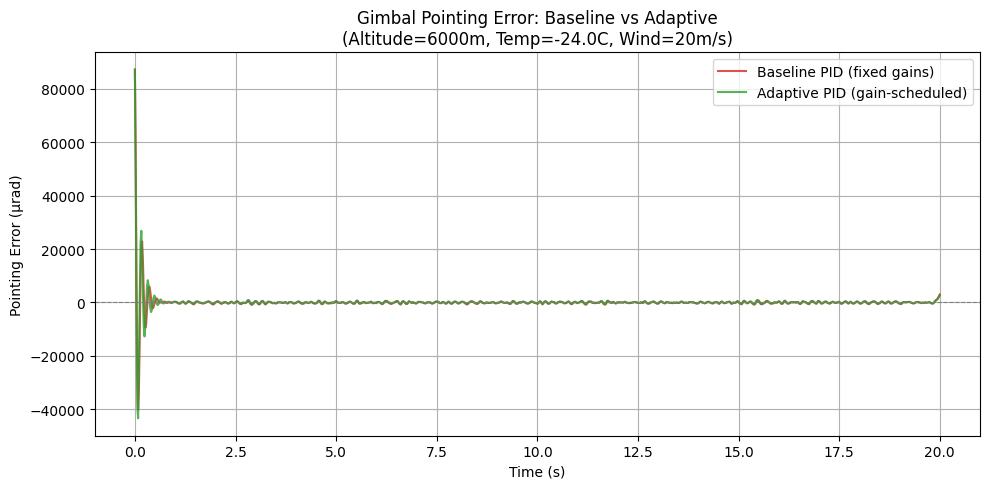


Day 3 complete. File saved: pointing_error_comparison.png


In [5]:
"""
Day 3 - Gimbal Pointing / Control Compensation (FIXED VERSION)
High Altitude Anti-Drone System Simulation (SIH Problem Statement 26050)

Fixes from v1:
- Wind disturbance torque no longer flips sign randomly every timestep
  (was physically unrealistic and caused derivative-term noise amplification)
- Adaptive gain scheduling is less aggressive, so it compensates without
  overshooting into oscillation
- Metrics now exclude the initial transient (first 2 seconds) so "max error"
  reflects settled tracking performance, not the starting condition
"""

import numpy as np
import matplotlib.pyplot as plt

T0 = 288.15
L = 0.0065

def isa_temperature(altitude_m):
    return T0 - L * altitude_m

def wind_gust_model(time_s, base_wind_speed=8.0, gust_amplitude=4.0,
                     gust_freq=0.2, noise_std=1.0, seed=42):
    rng = np.random.default_rng(seed)
    sinusoidal_gust = gust_amplitude * np.sin(2 * np.pi * gust_freq * time_s)
    turbulence = rng.normal(0, noise_std, size=len(time_s))
    wind_speed = base_wind_speed + sinusoidal_gust + turbulence
    return np.clip(wind_speed, 0, None)


# ---------------------------------------------------------
# 1. Gimbal Plant Model
# ---------------------------------------------------------
class GimbalAxis:
    def __init__(self, inertia=0.02):
        self.inertia = inertia
        self.angle = 0.0
        self.angular_velocity = 0.0

    def friction_coefficient(self, temp_c):
        base_friction = 0.05
        cold_penalty = max(0, (0 - temp_c)) * 0.004
        return base_friction + cold_penalty

    def step(self, motor_torque, disturbance_torque, temp_c, dt):
        friction = self.friction_coefficient(temp_c) * self.angular_velocity
        net_torque = motor_torque - friction - disturbance_torque
        angular_accel = net_torque / self.inertia

        self.angular_velocity += angular_accel * dt
        self.angle += self.angular_velocity * dt
        return self.angle


def wind_disturbance_series(wind_profile, drag_coefficient=0.0003):
    """
    Smooth, physically consistent disturbance torque: proportional to the
    signed deviation of wind speed from its own slow-moving average, so the
    direction doesn't flip chaotically every timestep.
    """
    smoothed = np.convolve(wind_profile, np.ones(15)/15, mode='same')
    deviation = wind_profile - smoothed
    return drag_coefficient * wind_profile * deviation


# ---------------------------------------------------------
# 2. PID Controller (with derivative filtering)
# ---------------------------------------------------------
class PIDController:
    def __init__(self, kp, ki, kd, d_filter_alpha=0.2):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.integral = 0.0
        self.prev_error = 0.0
        self.filtered_derivative = 0.0
        self.alpha = d_filter_alpha  # low-pass filter on derivative term

    def compute(self, error, dt):
        self.integral += error * dt
        self.integral = np.clip(self.integral, -50, 50)  # anti-windup

        raw_derivative = (error - self.prev_error) / dt if dt > 0 else 0.0
        # low-pass filter the derivative so wind noise doesn't get amplified
        self.filtered_derivative = (self.alpha * raw_derivative +
                                     (1 - self.alpha) * self.filtered_derivative)
        self.prev_error = error

        output = self.kp * error + self.ki * self.integral + self.kd * self.filtered_derivative
        return output


def gain_schedule(temp_c, wind_speed, base_kp=8.0, base_ki=0.5, base_kd=1.2):
    """
    Gentler adaptive scaling than v1 - enough to compensate for added
    friction/disturbance without pushing the loop into oscillation.
    """
    cold_factor = max(0, (0 - temp_c)) / 40.0
    wind_factor = wind_speed / 25.0
    severity = np.clip(cold_factor * 0.5 + wind_factor * 0.5, 0, 1)

    kp = base_kp * (1 + 0.35 * severity)
    ki = base_ki * (1 - 0.2 * severity)
    kd = base_kd * (1 + 0.25 * severity)
    return kp, ki, kd


# ---------------------------------------------------------
# 3. Simulation Run
# ---------------------------------------------------------
def run_simulation(target_angle_rad, altitude_m, wind_base_speed,
                    duration_s=20, dt=0.02, adaptive=False):
    n_steps = int(duration_s / dt)
    time = np.linspace(0, duration_s, n_steps)

    temp_c = isa_temperature(altitude_m) - 273.15
    wind_profile = wind_gust_model(time, base_wind_speed=wind_base_speed)
    disturbance_series = wind_disturbance_series(wind_profile)

    axis = GimbalAxis()

    if adaptive:
        kp, ki, kd = gain_schedule(temp_c, wind_base_speed)
    else:
        kp, ki, kd = 8.0, 0.5, 1.2

    pid = PIDController(kp, ki, kd)
    pointing_error_rad = np.zeros(n_steps)

    for i in range(n_steps):
        if adaptive:
            pid.kp, pid.ki, pid.kd = gain_schedule(temp_c, wind_profile[i])

        error = target_angle_rad - axis.angle
        motor_torque = pid.compute(error, dt)
        axis.step(motor_torque, disturbance_series[i], temp_c, dt)
        pointing_error_rad[i] = error

    return time, pointing_error_rad * 1e6, temp_c  # convert to microradians


# ---------------------------------------------------------
# 4. Compare Baseline vs Adaptive
# ---------------------------------------------------------
def compare_controllers(altitude_m=6000, wind_base_speed=20, target_deg=5):
    target_rad = np.radians(target_deg)

    time, err_baseline, temp_c = run_simulation(
        target_rad, altitude_m, wind_base_speed, adaptive=False)
    _, err_adaptive, _ = run_simulation(
        target_rad, altitude_m, wind_base_speed, adaptive=True)

    # Exclude the first 2 seconds (initial transient) from settled-performance metrics
    settle_idx = int(2 / 0.02)

    print(f"Scenario: altitude={altitude_m}m, temp={temp_c:.1f}C, wind={wind_base_speed}m/s")
    print(f"(Metrics below exclude the first 2s initial transient)\n")
    print(f"Baseline PID  - mean |error|: {np.mean(np.abs(err_baseline[settle_idx:])):.1f} urad, "
          f"max |error|: {np.max(np.abs(err_baseline[settle_idx:])):.1f} urad")
    print(f"Adaptive PID  - mean |error|: {np.mean(np.abs(err_adaptive[settle_idx:])):.1f} urad, "
          f"max |error|: {np.max(np.abs(err_adaptive[settle_idx:])):.1f} urad")

    plt.figure(figsize=(10, 5))
    plt.plot(time, err_baseline, label="Baseline PID (fixed gains)", color="tab:red", alpha=0.8)
    plt.plot(time, err_adaptive, label="Adaptive PID (gain-scheduled)", color="tab:green", alpha=0.8)
    plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    plt.title(f"Gimbal Pointing Error: Baseline vs Adaptive\n"
              f"(Altitude={altitude_m}m, Temp={temp_c:.1f}C, Wind={wind_base_speed}m/s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Pointing Error (µrad)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("pointing_error_comparison.png", dpi=150)
    plt.show()


# ---------------------------------------------------------
# 5. Run it
# ---------------------------------------------------------
if __name__ == "__main__":
    print("Running Day 3 simulation (fixed): baseline vs adaptive gimbal control\n")
    compare_controllers(altitude_m=6000, wind_base_speed=20, target_deg=5)
    print("\nDay 3 complete. File saved: pointing_error_comparison.png")